# Week 4 Homework: Predicting Diabetes with BRFSS Data

## Purpose of Homework

This homework assignment will help you practice building and evaluating a logistic regression model for classification. You will predict **whether someone has diabetes** using health status, health behaviors, healthcare access, and demographic data from the Behavioral Risk Factor Surveillance System (BRFSS).

You are encouraged to refer to lecture content and liberally use course resources such as the discussion board and office hours.

## Logistics

Due date: The homework is due 12:00pm on Thursday, February 5, 2026.

You will submit your homework on [MarkUs](https://markus.teach.cs.toronto.edu/markus/). 

1. Download this file (`STA272_hw4_student.ipynb`) from JupyterHub. (See [our JupyterHub Guide](../guides/jupyterhub_guide.ipynb) for detailed instructions.)
2. Submit this file to MarkUs under the hw4 assignment. (See [our MarkUs Guide](../guides/markus_guide.ipynb) for detailed instructions.)

All homeworks will take place in a Jupyter notebook (like this one). When you are done, you will download this notebook and submit it to MarkUs.

## About the Data

The **Behavioral Risk Factor Surveillance System (BRFSS)** is an annual health survey conducted by the CDC. It collects data on health-related risk behaviors, chronic health conditions, and use of preventive services from over 400,000 U.S. adults.

We will use a random sample of 75,000 observations from the 2024 BRFSS survey. The dataset contains many variables with cryptic labeling and coding of data and missing values. Your task is to select relevant variables, clean them, and build a model to predict diabetes status.

## Data Dictionary

Here are the variables you will work with:

### Outcome Variable
| Code | Description | Values |
|------|-------------|--------|
| `DIABETE4` | Diabetes status | 1=Yes, 2=Yes (pregnancy only), 3=No, 4=Pre-diabetes |

### Health Status
| Code | Description | Values |
|------|-------------|--------|
| `GENHLTH` | General health status | 1=Excellent, 2=Very good, 3=Good, 4=Fair, 5=Poor |
| `PHYSHLTH` | Days physical health not good (past 30 days) | 1-30, 88=None |
| `CVDINFR4` | Ever told you had a heart attack (MI) | 1=Yes, 2=No |
| `CVDCRHD4` | Ever told you had coronary heart disease | 1=Yes, 2=No |
| `HAVARTH4` | Ever told you had arthritis | 1=Yes, 2=No |

### Health Behaviors
| Code | Description | Values |
|------|-------------|--------|
| `SMOKE100` | Smoked 100+ cigarettes in life | 1=Yes, 2=No |
| `EXERANY2` | Exercise in past 30 days | 1=Yes, 2=No |
| `_BMI5` | BMI (multiply by 0.01 for actual value) | e.g., 2500 = 25.00 |

### Healthcare Access
| Code | Description | Values |
|------|-------------|--------|
| `PRIMINS2` | Primary source of health insurance | 1-10 (various types), 88=None |
| `MEDCOST1` | Could not see doctor due to cost (past 12 mo) | 1=Yes, 2=No |
| `CHECKUP1` | Last routine checkup | 1=Past year, 2=1-2 years, 3=2-5 years, 4=5+ years, 8=Never |

### Demographics
| Code | Description | Values |
|------|-------------|--------|
| `_AGE80` | Age (top-coded at 80) | 18-80 |
| `_SEX` | Sex | 1=Male, 2=Female |
| `EDUCA` | Education level | 1-6 (1=Never attended, 6=College graduate) |
| `INCOME3` | Income level | 1-11 (increasing income) |

### Missing Value Codes
- **7, 77, 777, 7777**: Don't know / Not sure
- **9, 99, 999, 9999**: Refused
- **BLANK/NaN**: Not asked or missing

## Task #1: Load the Data

Read `brfss_sample_raw.csv` into a pandas dataframe called `brfss`.

In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score

# Read the CSV file into a dataframe
brfss = pd.read_csv('brfss_sample_raw.csv')

# Display the shape and first few rows
print(f"Dataset shape: {brfss.shape}")
print(f"Number of variables: {brfss.shape[1]}")
brfss.head()

Dataset shape: (75000, 301)
Number of variables: 301


,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_LCSCTSN,_LCSPSTF,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK3,_RFDRHV9,_FLSHOT7,_PNEUMO3,_AIDTST4
0,27.0,6.0,b'07012024',b'07',b'01',b'2024',1200.0,b'2024007308',2.024007e+09,NaN,...,3.0,9.0,1.0,2.900000e+01,1.0,4.000000e+02,1.0,2.0,2.0,9.0
1,27.0,2.0,b'04012024',b'04',b'01',b'2024',1100.0,b'2024004862',2.024005e+09,NaN,...,4.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,NaN,NaN,2.0
2,20.0,2.0,b'04222024',b'04',b'22',b'2024',1100.0,b'2024006753',2.024007e+09,NaN,...,3.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,9.0
3,27.0,1.0,b'03212024',b'03',b'21',b'2024',1100.0,b'2024003069',2.024003e+09,NaN,...,4.0,9.0,1.0,5.700000e+01,1.0,4.000000e+02,1.0,NaN,NaN,2.0
4,34.0,2.0,b'02242024',b'02',b'24',b'2024',1100.0,b'2024002009',2.024002e+09,NaN,...,4.0,9.0,1.0,6.700000e+01,2.0,9.330000e+02,1.0,NaN,NaN,1.0


## Task #2: Select Variables

Using the data dictionary above, select the variables you need for analysis. Create a list called `selected_vars` containing the variable codes, then subset the dataframe to only include these columns.


In [7]:
# Select variables from the data dictionary
selected_vars = [
    # Outcome
    'DIABETE4',     # Diabetes status
    # Health Status
    'GENHLTH',      # General health
    'PHYSHLTH',     # Days physical health not good
    'CVDINFR4',     # Ever had heart attack
    'CVDCRHD4',     # Coronary heart disease
    'HAVARTH4',     # Arthritis
    # Health Behaviors
    'SMOKE100',     # Ever smoked
    'EXERANY2',     # Exercise
    '_BMI5',        # BMI
    # Healthcare Access
    'PRIMINS2',     # Primary insurance
    'MEDCOST1',     # Could not afford doctor
    'CHECKUP1',     # Last checkup
    # Demographics
    '_AGE80',       # Age
    '_SEX',         # Sex
    'EDUCA',        # Education
]

# Check which variables exist in the dataset
available_vars = [v for v in selected_vars if v in brfss.columns]
missing_vars = [v for v in selected_vars if v not in brfss.columns]
if missing_vars:
    print(f"Warning: Variables not found in dataset: {missing_vars}")

# Subset the dataframe
df = brfss[available_vars].copy()
print(f"\nSubset shape: {df.shape}")
df.head()


Subset shape: (75000, 15)


,DIABETE4,GENHLTH,PHYSHLTH,CVDINFR4,CVDCRHD4,HAVARTH4,SMOKE100,EXERANY2,_BMI5,PRIMINS2,MEDCOST1,CHECKUP1,_AGE80,_SEX,EDUCA
0,1.0,4.0,88.0,2.0,2.0,2.0,2.0,1.0,2845.0,3.0,1.0,1.0,67.0,1.0,1.0
1,3.0,3.0,88.0,2.0,2.0,2.0,2.0,1.0,3259.0,3.0,2.0,1.0,56.0,2.0,4.0
2,1.0,4.0,7.0,2.0,1.0,1.0,2.0,2.0,3366.0,3.0,2.0,1.0,79.0,2.0,6.0
3,3.0,3.0,88.0,2.0,2.0,2.0,2.0,1.0,3837.0,1.0,2.0,1.0,45.0,2.0,5.0
4,3.0,2.0,88.0,2.0,2.0,2.0,2.0,1.0,2720.0,1.0,2.0,1.0,28.0,1.0,6.0


## Task #3: Clean Missing Values

BRFSS uses special codes for missing values (7, 9, 77, 99, etc. for "Don't know" or "Refused"). Replace these codes with `NaN`.

Also handle the special case where `PHYSHLTH` uses 88 to mean "None" (0 days), and `CHECKUP1` uses 8 to mean "Never" (which we'll treat as a valid response, not missing).

**Hint:** Create a set of missing codes and use `.isin()` to identify them.

In [8]:
# Replace BRFSS missing codes with NaN
missing_codes = {7, 9, 77, 99, 777, 999, 7777, 9999}

for col in df.columns:
    df.loc[df[col].isin(missing_codes), col] = np.nan

# Special handling for PHYSHLTH: 88 means "None" (0 days)
if 'PHYSHLTH' in df.columns:
    df['PHYSHLTH'] = df['PHYSHLTH'].replace(88, 0)

# CHECKUP1: 8 means "Never" - this is a valid response, keep it

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
DIABETE4     159
GENHLTH      215
PHYSHLTH    3426
CVDINFR4     487
CVDCRHD4     761
HAVARTH4     426
SMOKE100    5194
EXERANY2     236
_BMI5       7021
PRIMINS2    7836
MEDCOST1     283
CHECKUP1     835
_AGE80      1372
_SEX           0
EDUCA        391
dtype: int64


## Task #4: Rename Variables

Rename the cryptic BRFSS codes to meaningful names using a dictionary and `.rename()`. Some have been done for you but please fill in the last three.

Also convert `_BMI5` to actual BMI values by dividing `bmi_raw` by 100 to create a variable named `bmi`.

In [9]:
# Rename columns to meaningful names
rename_dict = {
    'DIABETE4': 'diabetes',
    'GENHLTH': 'general_health',
    'PHYSHLTH': 'days_phys_bad',
    'CVDINFR4': 'heart_attack',
    'CVDCRHD4': 'heart_disease',
    'HAVARTH4': 'arthritis',
    'SMOKE100': 'ever_smoked',
    'EXERANY2': 'exercises',
    '_BMI5': 'bmi_raw',
    'PRIMINS2': 'insurance_type',
    'MEDCOST1': 'cost_barrier',
    'CHECKUP1': 'last_checkup',
    '_AGE80': 'age',
    '_SEX': 'sex',
    'EDUCA': 'education'
}

df = df.rename(columns={k: v for k, v in rename_dict.items() if k in df.columns})

# Convert BMI (divide by 100 to get actual value)
if 'bmi_raw' in df.columns:
    df['bmi'] = df['bmi_raw'] / 100
    df = df.drop(columns=['bmi_raw'])

print("Renamed columns:")
print(df.columns.tolist())
df.describe()

Renamed columns:
['diabetes', 'general_health', 'days_phys_bad', 'heart_attack', 'heart_disease', 'arthritis', 'ever_smoked', 'exercises', 'insurance_type', 'cost_barrier', 'last_checkup', 'age', 'sex', 'education', 'bmi']


,diabetes,general_health,days_phys_bad,heart_attack,heart_disease,arthritis,ever_smoked,exercises,insurance_type,cost_barrier,last_checkup,age,sex,education,bmi
count,74841.000000,74785.000000,71574.000000,74513.000000,74239.000000,74574.000000,69806.000000,74764.000000,67164.000000,74717.000000,74165.000000,73628.000000,75000.000000,74609.000000,67979.000000
mean,2.731685,2.645236,4.526490,1.941930,1.938456,1.654437,1.605836,1.234324,7.827631,1.903891,1.345325,54.561390,1.525400,5.025895,28.573747
std,0.728871,1.048390,8.988852,0.233878,0.240328,0.475555,0.488674,0.423578,20.814080,0.294743,0.900944,18.042041,0.499358,1.014108,6.587530
min,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,18.000000,1.000000,1.000000,12.110000
25%,3.000000,2.000000,0.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,40.000000,1.000000,4.000000,24.210000
50%,3.000000,3.000000,0.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,2.000000,1.000000,57.000000,2.000000,5.000000,27.440000
75%,3.000000,3.000000,3.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,2.000000,1.000000,70.000000,2.000000,6.000000,31.780000
max,4.000000,5.000000,30.000000,2.000000,2.000000,2.000000,2.000000,2.000000,88.000000,2.000000,8.000000,80.000000,2.000000,6.000000,98.440000


## Task #5: Create Binary Variables

Create a binary outcome variable called `has_diabetes` that equals 1 if the person has diabetes (original code = 1), and 0 otherwise (codes 2, 3, 4).

Also create binary versions of other categorical variables:
- `ever_smoked_binary`: 1 if ever smoked, 0 otherwise
- `exercises_binary`: 1 if exercises, 0 otherwise
- `had_heart_attack`: 1 if had heart attack (code = 1), 0 otherwise
- `has_heart_disease`: 1 if has coronary heart disease (code = 1), 0 otherwise
- `has_arthritis`: 1 if has arthritis (code = 1), 0 otherwise
- `is_male`: 1 if male, 0 if female
- `has_insurance`: 1 if has any insurance (codes 1-10), 0 if none (code = 88)
- `has_cost_barrier`: 1 if had cost barrier to care, 0 otherwise

In [10]:
# Create binary outcome: 1 = has diabetes, 0 = no diabetes
# Original: 1=Yes, 2=Yes (pregnancy), 3=No, 4=Pre-diabetes
df['has_diabetes'] = (df['diabetes'] == 1).astype(float)
df.loc[df['diabetes'].isna(), 'has_diabetes'] = np.nan

# Ever smoked: 1=Yes, 2=No -> 1=Yes, 0=No
if 'ever_smoked' in df.columns:
    df['ever_smoked_binary'] = (df['ever_smoked'] == 1).astype(float)
    df.loc[df['ever_smoked'].isna(), 'ever_smoked_binary'] = np.nan

# Exercises: 1=Yes, 2=No -> 1=Yes, 0=No
if 'exercises' in df.columns:
    df['exercises_binary'] = (df['exercises'] == 1).astype(float)
    df.loc[df['exercises'].isna(), 'exercises_binary'] = np.nan

# Heart attack: 1=Yes, 2=No -> 1=Yes, 0=No
if 'heart_attack' in df.columns:
    df['had_heart_attack'] = (df['heart_attack'] == 1).astype(float)
    df.loc[df['heart_attack'].isna(), 'had_heart_attack'] = np.nan

# Coronary heart disease: 1=Yes, 2=No -> 1=Yes, 0=No
if 'heart_disease' in df.columns:
    df['has_heart_disease'] = (df['heart_disease'] == 1).astype(float)
    df.loc[df['heart_disease'].isna(), 'has_heart_disease'] = np.nan

# Arthritis: 1=Yes, 2=No -> 1=Yes, 0=No
if 'arthritis' in df.columns:
    df['has_arthritis'] = (df['arthritis'] == 1).astype(float)
    df.loc[df['arthritis'].isna(), 'has_arthritis'] = np.nan

# Sex: 1=Male, 2=Female -> 1=Male, 0=Female
if 'sex' in df.columns:
    df['is_male'] = (df['sex'] == 1).astype(float)
    df.loc[df['sex'].isna(), 'is_male'] = np.nan

# Has insurance: 1-10 = various types, 88 = None -> 1=Has insurance, 0=None
if 'insurance_type' in df.columns:
    df['has_insurance'] = ((df['insurance_type'] >= 1) & (df['insurance_type'] <= 10)).astype(float)
    df.loc[df['insurance_type'].isna(), 'has_insurance'] = np.nan

# Cost barrier: 1=Yes, 2=No -> 1=Yes, 0=No
if 'cost_barrier' in df.columns:
    df['has_cost_barrier'] = (df['cost_barrier'] == 1).astype(float)
    df.loc[df['cost_barrier'].isna(), 'has_cost_barrier'] = np.nan

print("Distribution of diabetes (binary):")
print(df['has_diabetes'].value_counts(dropna=False))
print(f"\nPercentage with diabetes: {df['has_diabetes'].mean()*100:.1f}%")

Distribution of diabetes (binary):
has_diabetes
0.0    64156
1.0    10685
NaN      159
Name: count, dtype: int64

Percentage with diabetes: 14.3%


## Task #6: Visualize the Outcome

Make a bar plot showing the distribution of the outcome variable (`has_diabetes`).

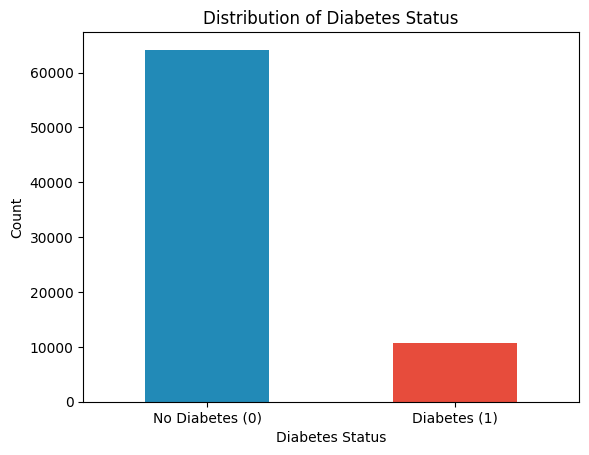

In [11]:
# Bar plot of outcome distribution
counts = df['has_diabetes'].value_counts().reindex([0, 1])

ax = counts.plot(kind='bar', color=["#228ab7", "#e74c3c"])
ax.set_xticklabels(['No Diabetes (0)', 'Diabetes (1)'], rotation=0)
plt.xlabel('Diabetes Status')
plt.ylabel('Count')
plt.title('Distribution of Diabetes Status')
plt.show()

## Task #7: Explore Predictors

Create boxplots comparing `bmi` and `age` between those with and without diabetes.

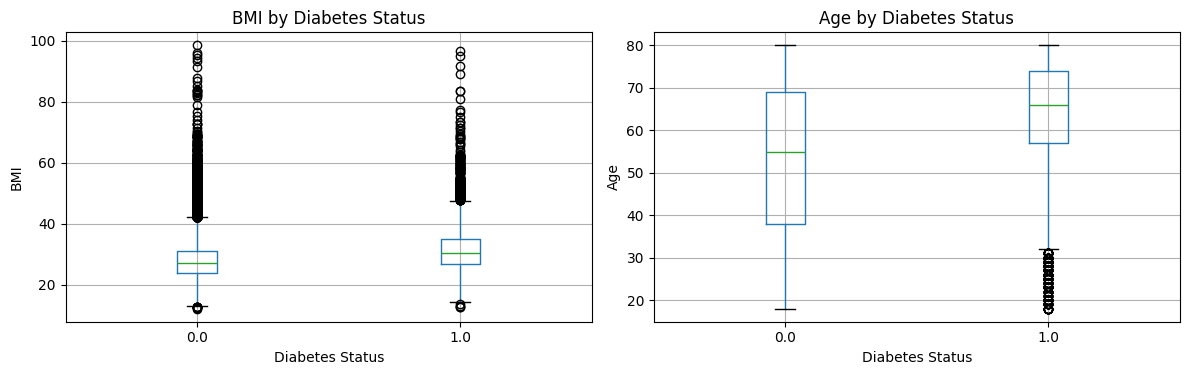

In [12]:
# Boxplot: BMI and Age by diabetes status
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.boxplot(column='bmi', by='has_diabetes', ax=axes[0])
axes[0].set_xlabel('Diabetes Status')
axes[0].set_ylabel('BMI')
axes[0].set_title('BMI by Diabetes Status')

df.boxplot(column='age', by='has_diabetes', ax=axes[1])
axes[1].set_xlabel('Diabetes Status')
axes[1].set_ylabel('Age')
axes[1].set_title('Age by Diabetes Status')

plt.suptitle('')
plt.tight_layout()
plt.show()

## Task #8: Prepare Data for Modeling

Select features for the model, check for missing values, and remove rows with missing data in key variables. Store the result in `df_clean`.

In [13]:
# Select features for the model
feature_cols = [
    # Demographics
    'age',
    'is_male',
    'education',
    # Health Status
    'general_health',
    'had_heart_attack',
    'has_heart_disease',
    'has_arthritis',
    # Health Behaviors
    'bmi',
    'ever_smoked_binary',
    'exercises_binary',
    # Healthcare Access
    'has_insurance',
]

# Keep only features that exist
feature_cols = [c for c in feature_cols if c in df.columns]
print(f"Features for model: {feature_cols}")

# Create analysis dataset
analysis_vars = feature_cols + ['has_diabetes']
df_clean = df[analysis_vars].dropna()

print(f"\nComplete cases: {len(df_clean)} out of {len(df)} ({100*len(df_clean)/len(df):.1f}%)")

Features for model: ['age', 'is_male', 'education', 'general_health', 'had_heart_attack', 'has_heart_disease', 'has_arthritis', 'bmi', 'ever_smoked_binary', 'exercises_binary', 'has_insurance']

Complete cases: 56494 out of 75000 (75.3%)


In [14]:
# Define X and y
X = df_clean[feature_cols]
y = df_clean['has_diabetes']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} observations")
print(f"Test set: {len(X_test)} observations")
print(f"\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))

Training set: 45195 observations
Test set: 11299 observations

Class distribution in training set:
has_diabetes
0.0    0.862042
1.0    0.137958
Name: proportion, dtype: float64


## Task #9: Fit Logistic Regression

Fit a logistic regression model using `statsmodels` on the training data. Display the model summary.

**Hint:** Remember to add a constant term using `sm.add_constant()`.

In [15]:
# Add constant and fit logistic regression
X_train_const = sm.add_constant(X_train)
model = sm.Logit(y_train, X_train_const).fit()

# Display summary
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.337494
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           has_diabetes   No. Observations:                45195
Model:                          Logit   Df Residuals:                    45183
Method:                           MLE   Df Model:                           11
Date:                Sat, 31 Jan 2026   Pseudo R-squ.:                  0.1589
Time:                        13:31:38   Log-Likelihood:                -15253.
converged:                       True   LL-Null:                       -18134.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -7.4825      0.157    -47.768      0.000      -7.789      -7.175
age  

In [16]:
# Display coefficients and odds ratios
results = pd.DataFrame({
    'Coefficient': model.params,
    'Odds Ratio': np.exp(model.params),
    'P-value': model.pvalues
})
print("\nCoefficients and Odds Ratios:")
print(results.round(4))


Coefficients and Odds Ratios:
                    Coefficient  Odds Ratio  P-value
const                   -7.4825      0.0006   0.0000
age                      0.0389      1.0397   0.0000
is_male                  0.2372      1.2677   0.0000
education               -0.0808      0.9224   0.0000
general_health           0.5022      1.6523   0.0000
had_heart_attack         0.3651      1.4406   0.0000
has_heart_disease        0.2641      1.3023   0.0000
has_arthritis            0.0798      1.0830   0.0131
bmi                      0.0638      1.0659   0.0000
ever_smoked_binary      -0.0757      0.9271   0.0131
exercises_binary        -0.2651      0.7671   0.0000
has_insurance            0.4336      1.5428   0.0000


## Task #10: Model Evaluation

Make predictions on the test set using a threshold of 0.5. Calculate the confusion matrix and classification metrics (accuracy, precision, recall, F1 score).

In [17]:
# Make predictions on test set
X_test_const = sm.add_constant(X_test)
y_pred_prob = model.predict(X_test_const)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(f"                    Predicted")
print(f"                No Diabetes  Diabetes")
print(f"Actual No Diabetes   {cm[0,0]:6d}    {cm[0,1]:6d}")
print(f"       Diabetes      {cm[1,0]:6d}    {cm[1,1]:6d}")

# Classification metrics
print(f"\nClassification Metrics:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

Confusion Matrix:
                    Predicted
                No Diabetes  Diabetes
Actual No Diabetes     9583       157
       Diabetes        1407       152

Classification Metrics:
Accuracy:  0.8616
Precision: 0.4919
Recall:    0.0975
F1 Score:  0.1627


## Task #11: ROC Curve

Create a ROC curve and calculate the AUC (Area Under the Curve).

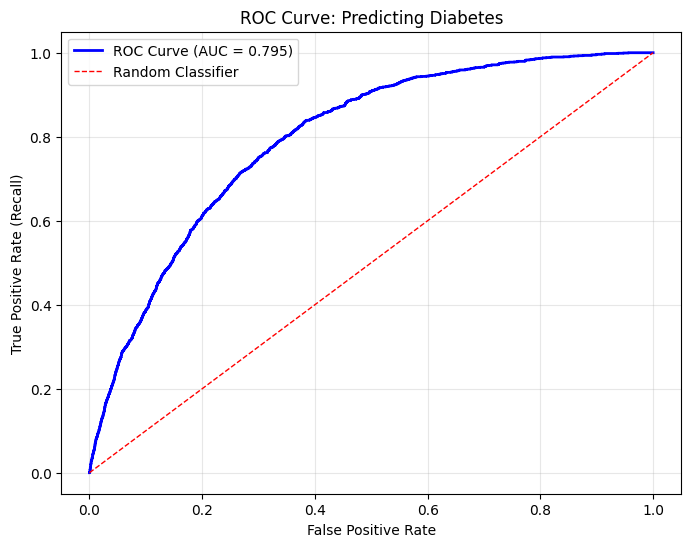


AUC = 0.795


In [18]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)

# Create the ROC plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve: Predicting Diabetes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nAUC = {auc:.3f}")

## Question #1 (4 points)

Based on the plots in Tasks #6 and #7

a) Describe the counts of `has_diabetes` specifiying whether there is a potential issue with class imbalance.

b) Is there evidence of a difference in `bmi` and `age` by diabetes status?

### Student Answer:

*a) There are 14.3% of the BRFSS sample that have diabetes. This small percentange indicates that there is the potential for class imbalance that might impact our prediction model (many 0s not many 1s).*

*b) The boxplots show a difference in bmi with diabetes status. The median bmi level is higher for those with diabetes (so are the other quantiles 25th, 75th). Similarly, median age (and 25th and 75th percentile) is higher for those with diabetes.*

---

Based on the logistic regression output from Task #9:

c) Interpret the odds ratios for `bmi` and `has_insurance`


### Student Answer:

*Odds ratio for `bmi` = 1.0659. Holding the other variables constant, a 1-unit increase in BMI (1 kg/m^2) is associated with 6.6% higher odds of diabetes. P-value < 0.001 indicates strong statistical evidence of an association in this model.*

*Odds ratio for `has_insurance` = 1.5428. Adjusting for the other variables in the model, people who have health insurance have about 54% higher odds of having diabetes than those without insurance. P-value < 0.001 indicates strong statistical evidence of an association in this model.*


---

**To obtain full marks (4 points):**
- Correctly discuss bar plot (0.5 point)
- Correctly interpret box plots (1.5 point)
- Correctly interpret the 2 odds ratios (2 points)

## Question #2 (4 points)

Based on the classification metrics and ROC curve from Tasks #10 and #11:

a) What does the accuracy value tell us about the model's performance in identifying people who have diabetes?

b) What does the recall value tell us about the model's performance in identifying people who have diabetes?

c) What does the AUC value tell us about the model's discriminative ability?

d) If a clinic were using this model to screen patients for diabetes risk, would they be more concerned about false positives or false negatives? Explain why.

**To obtain full marks (4 points):**
- Correctly interpret the accuracy and recall metrics (1 point)
- Correctly interpret the AUC value (1 point)
- Identify whether false positives or false negatives are more concerning (1 point)
- Provide a clear justification in context (1 point)

### Student Answer:

*a) Accuracy (0.8616) tells us the model is correct about 86% of the time overall across both classes (diabetes and no diabetes). In an imbalanced problem like diabetes in BRFSS (many more “no diabetes” than “yes diabetes”), high accuracy can happen even if the model does not predict “has diabetes” very well.*

*b) Recall = 0.0975 (sensitivity) means: among people who actually have diabetes, our model correctly identifies only about 9.8% of them. A recall of 9.75% means the model correctly flags only about 1 out of 10 true diabetes cases, and misses about 9 out of 10 (many false negatives).*

*c) Given the model’s very low recall (0.0975), it’s currently producing many false negatives, which is the bigger concern.* 

*d) False negatives are more concerning in this context because a false negative means a person who actually has diabetes is told (by the model) they don’t. As a result with this model a person may not get confirmatory testing, monitoring, or early treatment. That delay can result in negative symptoms from undiagnosed diabetes.*
